# the purpose of this notebook is to generate a multipose split plot

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:
figure_path = Path("figures")
figure_tag = Path("07_multipose_split")

In [3]:
def get_svg(fig_name) -> Path:
    return figure_path / f"{figure_tag}_{fig_name}.svg"

def get_png(fig_name) -> Path:
    return figure_path / f"{figure_tag}_{fig_name}.png"

def save_both(fig_name):
    plt.savefig(get_svg(fig_name), format='svg', bbox_inches='tight')
    plt.savefig(get_png(fig_name), format='png', bbox_inches='tight')

# def save_both(fig, fig_name=""):
#     fig.write_image(get_svg(fig_name))
#     fig.write_image(get_png(fig_name))

In [4]:
# I'll end up want to use different data, I'd like to convert this into a python script
raw_df = pd.read_csv("/data1/choderaj/paynea/asap-datasets/20250212_p_to_x_posit/multipose_split/combined_results.csv", index_col=0)

In [5]:
raw_df.columns

Index(['StructureChoice', 'StructureChoice_Choose_N', 'Score',
       'Score_Choose_N', 'EvaluationMetric', 'EvaluationMetric_Cutoff',
       'Split', 'N_Per_Split', 'Reference_Structure_Column', 'PoseSelection',
       'PoseSelection_Choose_N', 'Min', 'Max', 'CI_Upper', 'CI_Lower', 'Total',
       'Fraction', 'source_file'],
      dtype='object')

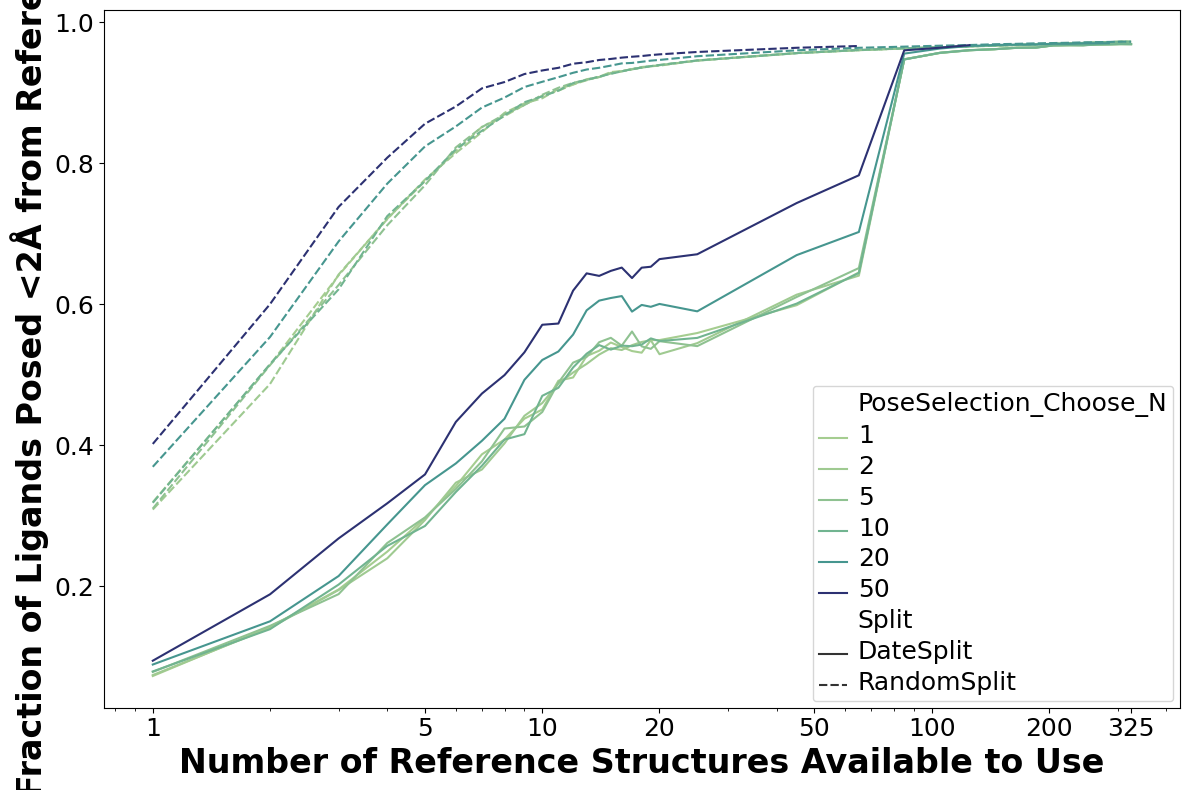

In [7]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt

# Set global font to Helvetica

plt.figure(figsize=(12, 8))
fig = sns.lineplot(data=raw_df,
                  x="N_Per_Split",
                  y="Fraction",
                  hue="PoseSelection_Choose_N",
                  style="Split",
                  palette='crest')

# Set font sizes
title_font_size = 24
text_font_size = 18

# Add labels with bold font and specified sizes
plt.xlabel('Number of Reference Structures Available to Use', 
          fontsize=title_font_size, 
          fontweight='bold',
          )
plt.ylabel('Fraction of Ligands Posed <2Å from Reference', 
          fontsize=title_font_size, 
          fontweight='bold',
          )

# Set x-axis to log scale but show raw numbers
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

# Set custom tick locations with specified font size
custom_ticks = [1, 5, 10, 20, 50, 100, 200, raw_df["N_Per_Split"].max()]
plt.xticks(custom_ticks, custom_ticks, fontsize=text_font_size)
plt.yticks(fontsize=text_font_size)

# Update legend font size
legend = plt.legend()
plt.setp(legend.get_title(), fontsize=title_font_size, fontweight='bold')
plt.setp(legend.get_texts(), fontsize=text_font_size)

plt.tight_layout()

fig_name = "comparison"
plt.savefig(get_svg(fig_name), format='svg', bbox_inches='tight')
plt.savefig(get_png(fig_name), format='png', bbox_inches='tight')